In [1]:
from google.colab import drive
drive.mount('/content/drive')  #Permettre le fichier d'avoir accès a mon drive

Mounted at /content/drive


<p style="text-align:center; font-size:3.3em; color:#AD7D67; line-height:5rem; font-style:italic; font-weight:700;">
    Projet Data Analyse :<br>
    L'attrition des clients d'une banque</p>
<p style="text-align:center; font-size:2.8em; color:#9EBEB8; line-height:4rem; font-style:italic; font-weight:700;">
    Partie 2
</p>

<h1>Sommaire<span class="tocSkip"></span></h1>
<div class="toc">
    <ul class="toc-item">
        <li><span><a href="#Contexte-et-Objectif" data-toc-modified-id="Contexte-et-Objectif"><span class="toc-item-num">1&nbsp;&nbsp;</span>Contexte et Objectif</a></span></li>
        <li><span><a href="#Obtenir-les-données" data-toc-modified-id="Obtenir-les-données"><span class="toc-item-num">2&nbsp;&nbsp;</span>Obtenir les données</a></span></li>
        <li><span><a href="#Visualisation-des-données" data-toc-modified-id="Visualisation-des-données"><span class="toc-item-num">3&nbsp;&nbsp;</span>Visualisation des données</a></span></li>
        <li><span><a href="#Volume-des-actions-négociées-chaque-jour" data-toc-modified-id="Volume-des-actions-négociées-chaque-jour"><span class="toc-item-num">4&nbsp;&nbsp;</span>Volume des actions négociées chaque jour</a></span></li>
                <li><span><a href="#Total-Traded" data-toc-modified-id="Total-Traded"><span class="toc-item-num">5&nbsp;&nbsp;</span>Total Traded</a></span></li>
                <li><span><a href="#Relation-entre-les-actions-de-Tesla-et-celles-de-Ford" data-toc-modified-id="Relation-entre-les-actions-de-Tesla-et-celles-de-Ford"><span class="toc-item-num">6&nbsp;&nbsp;</span>Relation entre les actions de Tesla et celles de Ford</a></span></li>
                <li><span><a href="#Rendement" data-toc-modified-id="Rendement"><span class="toc-item-num">7&nbsp;&nbsp;</span>Rendement</a></span></li>
                <li><span><a href="#Rendements-quotidiens-cumulatifs" data-toc-modified-id="Rendements-quotidiens-cumulatifs"><span class="toc-item-num">8&nbsp;&nbsp;</span>Rendements quotidiens cumulatifs</a></span></li>
                <li><span><a href="#Saisonnabilité" data-toc-modified-id="Saisonnabilité"><span class="toc-item-num">9&nbsp;&nbsp;</span>Saisonnabilité</a></span>
                <li><span><a href="#Analyse-de-la-tendance" data-toc-modified-id="Analyse-de-la-tendance"><span class="toc-item-num">10&nbsp;&nbsp;</span>Analyse de la tendance</a></span>
                            <ul class="toc-item">
                                <li><span><a href="#Lissage-par-moyenne-mobile-simple" data-toc-modified-id="Lissage-par-moyenne-mobile-simple"><span class="toc-item-num">10.1&nbsp;&nbsp;</span>Lissage par moyenne mobile simple</a></span></li>
                                <li><span><a href="#Lissage-par-moyenne-mobile-exponentielle" data-toc-modified-id="Lissage-par-moyenne-mobile-exponentielle"><span class="toc-item-num">10.2&nbsp;&nbsp;</span>Lissage par moyenne mobile exponentielle</a></span></li>
                               <li><span><a href="#Bandes-de-BOLLINGER" data-toc-modified-id="Bandes-de-BOLLINGER"><span class="toc-item-num">10.3&nbsp;&nbsp;</span>Bandes de BOLLINGER</a></span></li>
                    </ul>
                </li>
            </ul>
        </li>
    </ul>
</div>









# **Contexte et Objectif**

Pour justifier ces bons résultats, la banque décide de fournir des actualités financières sur les cotations boursières qu’elle a plébicitées et sur lesquelles elle s’est appuyée pour proposer une qualité de service irréprochable.
L’objectif est ici de procéder a l’extraction des informations et a trouver des cotations d’entreprises a partir de symboles ou de noms.
Les actions a traiter sont ”Tesla”, ”Ford”, .... Une fois la cotation trouvée, il est proposé de représenter ses performances graphiquement en fonction de différents indicateurs, paramètres et durées.

Cette partie est principalement porté sur l'apprentissage des bibliothéques, des techniques financières et des plateformes de trading quantitatif.

Nous analyserons les données sur les actions de quelques compagnies automobiles (Tesla et Ford) du 1er janvier 2017 au 1er janvier 2023.

##Importations des différentes bibliothèques

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# **Obtenir les données**

Nous allons utiliser yahoo finance pour obtenir les informations historiques sur les actions de Tesla du 1er janvier 2017 au 1er janvier 2023.


In [3]:

import datetime as dt
import yfinance as yf


In [4]:
start = dt.datetime(2017,1,1)
end = dt.datetime(2023,1,1)

In [5]:
tesla = yf.download('TSLA', start, end)

[*********************100%%**********************]  1 of 1 completed


In [6]:
tesla.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-01-03,14.324000,14.688667,14.064000,14.466000,14.466000,88849500
2017-01-04,14.316667,15.200000,14.287333,15.132667,15.132667,168202500
2017-01-05,15.094667,15.165333,14.796667,15.116667,15.116667,88675500
2017-01-06,15.128667,15.354000,15.030000,15.267333,15.267333,82918500
2017-01-09,15.264667,15.461333,15.200000,15.418667,15.418667,59692500


**La deuxième entreprise automobile**

Reprenons les mêmes étapes pour extraire les données pour Ford

In [7]:
ford = yf.download('F', start, end)

[*********************100%%**********************]  1 of 1 completed


In [8]:
ford.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-01-03,12.20,12.60,12.13,12.59,8.708390,40510800
2017-01-04,12.77,13.27,12.74,13.17,9.109569,77638100
2017-01-05,13.21,13.22,12.63,12.77,8.832896,75628400
2017-01-06,12.80,12.84,12.64,12.76,8.825976,40315900
2017-01-09,12.79,12.86,12.63,12.63,8.736059,39438400


# **Visualisation des données**

Nous allons faire le tracé linéaire de tous les prix à l'ouverture des différentes actions.

In [9]:
import plotly.express as px

# Créer un graphique à l'aide de Plotly Express
fig = px.line(tesla, x=tesla.index, y='Open', title='Open Price')

# Afficher le graphique
fig.show()

In [10]:
import plotly.express as px

# Créer un graphique à l'aide de Plotly Express
fig = px.line(ford, x=ford.index, y='Open', title='Open Price')

# Afficher le graphique
fig.show()

La visualisation du prix à l'ouverture des séries temporelles donne l'impression que Tesla a toujours eu beaucoup plus de valeur en tant qu'entreprise que Ford. Mais pour vraiment comprendre cela, il faudrait regarder la capitalisation boursière totale de la société, et pas seulement le cours de l'action. Malheureusement, nos données actuelles n'ont pas cette information du nombre total d'unités d'actions présentes. Mais ce que nous pouvons faire comme simple calcul pour essayer de représenter l'argent total échangé serait de multiplier la colonne 'Volume' par le cours de l'action. Rappelez-vous que ce n'est pas encore la capitalisation boursière réelle, c'est juste une représentation visuelle de la quantité totale d'argent échangé en utilisant la série temporelle.

# **Volume des actions négociées chaque jour**

In [11]:
import plotly.graph_objects as go

# Créer la figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Volume' de Tesla
fig.add_trace(go.Scatter(x=tesla.index, y=tesla['Volume'], mode='lines', name='Tesla'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Volume Traded',
                  xaxis_title='Date',
                  yaxis_title='Volume')

# Afficher la figure
fig.show()

In [12]:
# Créer la figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Volume' de Ford
fig.add_trace(go.Scatter(x=ford.index, y=ford['Volume'], mode='lines', name='Ford'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Volume Traded',
                  xaxis_title='Date',
                  yaxis_title='Volume')

# Afficher la figure
fig.show()

In [13]:
tesla['Volume'].idxmax()

Timestamp('2020-02-04 00:00:00')

In [14]:
ford['Volume'].idxmax()

Timestamp('2022-01-04 00:00:00')

En remarque, il semble que Tesla ait eu un très gros pic au premier trimestre de l'année 2020 , plus précisement le 04/02/2020. Celui de Ford est pour le 04/01/2022.

# **Total Traded**: Création d'une colonne qui est le prix d'ouverture multiplié par le Volume négocié.

In [15]:
tesla['Total Traded'] = tesla['Open']*tesla['Volume']
ford['Total Traded'] = ford['Open']*ford['Volume']

In [16]:
import plotly.graph_objects as go

# Créer la figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Total Traded' de Tesla
fig.add_trace(go.Scatter(x=tesla.index, y=tesla['Total Traded'], mode='lines', name='Tesla'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Total Traded',
                  xaxis_title='Date',
                  yaxis_title='Total Traded')

# Afficher la figure
fig.show()

Au cours de cette période, Tesla a réalisé des progrès significatifs vers la rentabilité, enregistrant plusieurs trimestres consécutifs de bénéfices. Cette performance a été saluée par les investisseurs et les analystes, conduisant à une augmentation spectaculaire du cours des actions de l'entreprise et à son inclusion dans l'indice S&P 500, renforçant ainsi sa légitimité en tant que leader de l'industrie automobile.

D'ou ce pic en fin 2020.

In [17]:
import plotly.graph_objects as go

# Créer la figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Total Traded' de Ford
fig.add_trace(go.Scatter(x=ford.index, y=ford['Total Traded'], mode='lines', name='Ford'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Total Traded',
                  xaxis_title='Date',
                  yaxis_title='Total Traded')

# Afficher la figure
fig.show()

Ford a accéléré sa transition vers l'électrification en annonçant des plans ambitieux pour développer une gamme de véhicules électriques, y compris des modèles emblématiques tels que le Ford Mustang Mach-E et le Ford F-150 Lightning. Ces annonces ont été bien accueillies par les investisseurs et les consommateurs, renforçant la position de Ford dans le segment des véhicules électriques.

La pandémie de COVID-19 a présenté des défis significatifs pour l'ensemble de l'industrie automobile, y compris Ford. L'entreprise a dû faire face à des interruptions de la chaîne d'approvisionnement, à une baisse de la demande des consommateurs et à des perturbations dans la production. Ford a rapidement réagi en mettant en œuvre des mesures de sécurité pour ses employés, en ajustant sa production en fonction de la demande et en lançant des initiatives pour soutenir les communautés touchées par la pandémie.

In [18]:
tesla['Total Traded'].idxmax()

Timestamp('2020-12-18 00:00:00')

In [19]:
ford['Total Traded'].idxmax()

Timestamp('2022-01-04 00:00:00')

Il a eu une énorme quantité d'argent échangé pour Tesla en fin 2020, plus précisement le 18/12/2020 et celle de Ford le 04/01/2022.

# **Relation entre les actions de Tesla et de Ford**

**Enfin, voyons s'il existe une relation entre ces actions car elles sont tous liées à l'industrie automobile. Nous pouvons le voir facilement à travers un diagramme de dispersion.**

In [20]:
from pandas.plotting import scatter_matrix
car_comp = pd.concat([tesla['Open'], ford['Open']], axis=1)

In [21]:
car_comp.columns = ['Tesla Open', 'Ford Open']
car_comp.head()

,Tesla Open,Ford Open
Date,,
2017-01-03,14.324000,12.20
2017-01-04,14.316667,12.77
2017-01-05,15.094667,13.21
2017-01-06,15.128667,12.80
2017-01-09,15.264667,12.79


array([[<Axes: xlabel='Tesla Open', ylabel='Tesla Open'>,
        <Axes: xlabel='Ford Open', ylabel='Tesla Open'>],
       [<Axes: xlabel='Tesla Open', ylabel='Ford Open'>,
        <Axes: xlabel='Ford Open', ylabel='Ford Open'>]], dtype=object)

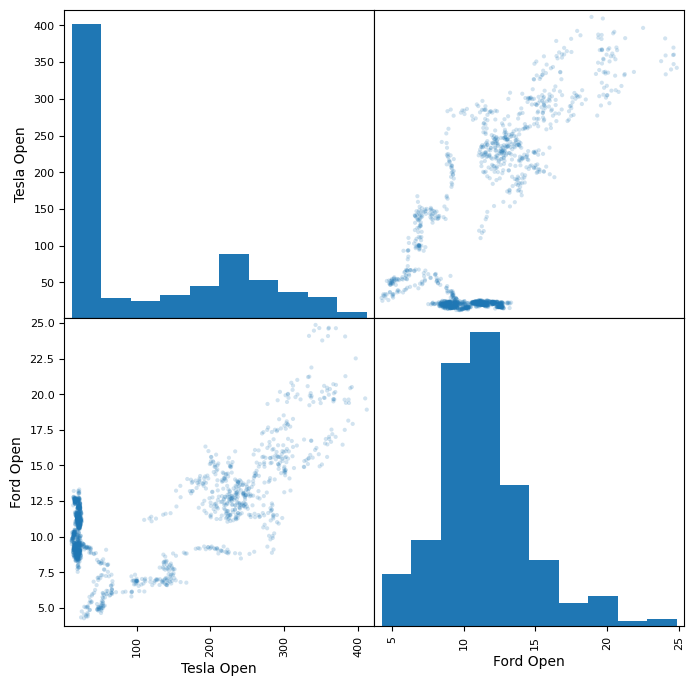

In [22]:
scatter_matrix(car_comp, figsize=(8,8), alpha=0.2)

De manière générale, à l'ouverture Tesla et Ford évoluent dans le même sens, une augmentation des actions de Tesla entraîne une augmentation des actions de Ford, du même ordre quelle que soit la valeur des actions de Tesla.

# **Rendement**

**Créons une nouvelle colonne pour chaque dataframe appelée "returns". Cette colonne sera calculée à partir de la colonne de prix à la fermeture 'Close'.**

### Méthode pct_change

In [23]:
tesla['returns'] = tesla['Close'].pct_change(1)
tesla['returns']  #Affichage de la colonne 'returns' de tesla

Date
2017-01-03         NaN
2017-01-04    0.046085
2017-01-05   -0.001057
2017-01-06    0.009967
2017-01-09    0.009912
                ...   
2022-12-23   -0.017551
2022-12-27   -0.114089
2022-12-28    0.033089
2022-12-29    0.080827
2022-12-30    0.011164
Name: returns, Length: 1510, dtype: float64

In [24]:
tesla.head()

,Open,High,Low,Close,Adj Close,Volume,Total Traded,returns
Date,,,,,,,,
2017-01-03,14.324000,14.688667,14.064000,14.466000,14.466000,88849500,1.272680e+09,NaN
2017-01-04,14.316667,15.200000,14.287333,15.132667,15.132667,168202500,2.408099e+09,0.046085
2017-01-05,15.094667,15.165333,14.796667,15.116667,15.116667,88675500,1.338527e+09,-0.001057
2017-01-06,15.128667,15.354000,15.030000,15.267333,15.267333,82918500,1.254446e+09,0.009967
2017-01-09,15.264667,15.461333,15.200000,15.418667,15.418667,59692500,9.111861e+08,0.009912


In [25]:
ford['returns'] = ford['Close'].pct_change(1) #Variation par rapport à la veille
ford.head() #Affichage sous forme de dataframe

,Open,High,Low,Close,Adj Close,Volume,Total Traded,returns
Date,,,,,,,,
2017-01-03,12.20,12.60,12.13,12.59,8.708390,40510800,4.942318e+08,NaN
2017-01-04,12.77,13.27,12.74,13.17,9.109569,77638100,9.914386e+08,0.046068
2017-01-05,13.21,13.22,12.63,12.77,8.832896,75628400,9.990512e+08,-0.030372
2017-01-06,12.80,12.84,12.64,12.76,8.825976,40315900,5.160435e+08,-0.000783
2017-01-09,12.79,12.86,12.63,12.63,8.736059,39438400,5.044171e+08,-0.010188


Quand c'est positif ,il gagne de l'argent. Dans le cas contraire il en perd.

Maintenant, traçons un histogramme des rendements de chaque entreprise séparement et empiler.

<Axes: >

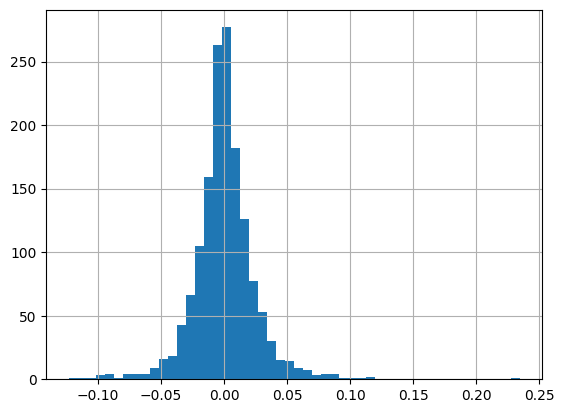

In [26]:
ford['returns'].hist(bins=50)

Ils sont centrés sur 0

<Axes: >

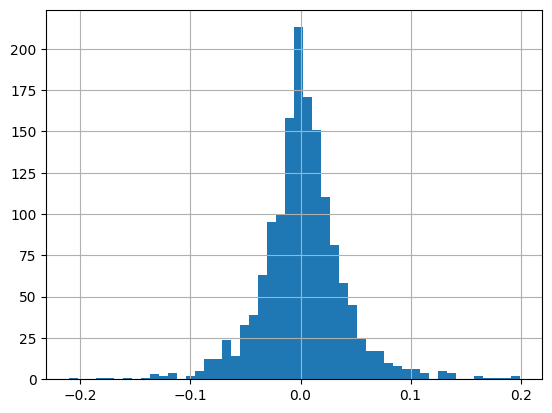

In [27]:
tesla['returns'].hist(bins=50)

Tesla est intéressant car la distribution est un peu plus large. Elle va de -0,2 à plus de 0,2.
C'est une distribution différente de celle de Ford.

Traçons ces deux différentes graphiques pour les comparées.

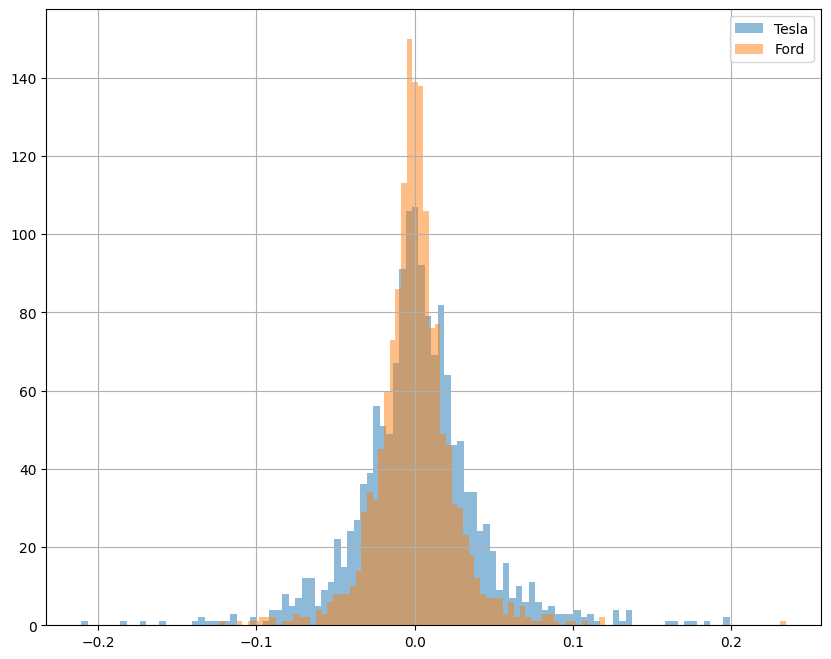

In [28]:
tesla['returns'].hist(bins=100, label='Tesla', figsize=(10,8), alpha=0.5)
ford['returns'].hist(bins=100, label='Ford', alpha=0.5)
plt.legend();

Au vu du graphique précédent, on constate que Ford est plus stable et le pique est très proches de 0.

Tesla est totalement différent, on remarque une grande volatilité avec une distrubution plus large, plus étendue

###Traçons une estimation de densité de noyau KDE pour avoir un point de vu différent.

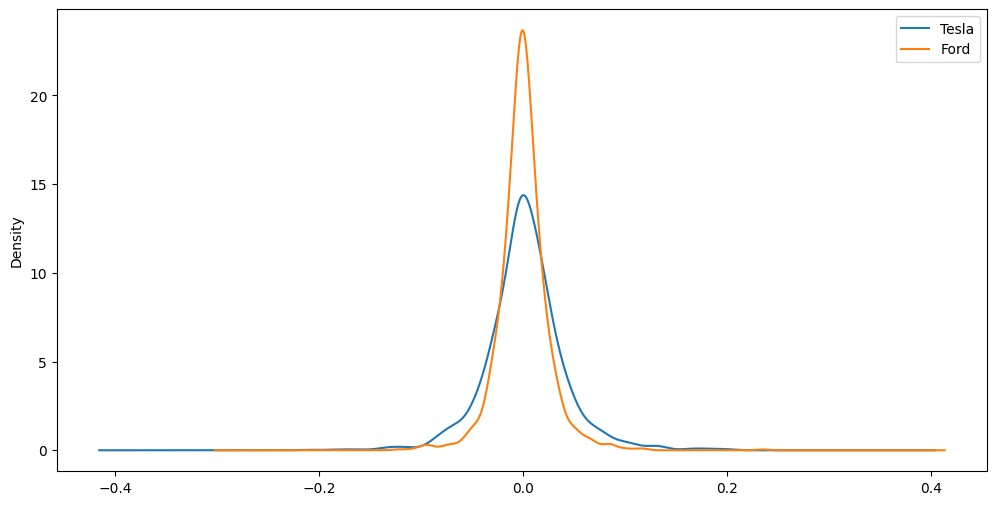

In [29]:
tesla['returns'].plot(kind='kde', label='Tesla', figsize=(12,6))
ford['returns'].plot(kind='kde', label='Ford')
plt.legend();

On constate que la courbe de 'Tesla' est plus large car il y'a plus de volatilité.

## **Rendements quotidiens cumulatifs**

Nous sommes désormais en mesure d'identifier le titre qui a enregistré l'écart de rendement quotidien le plus important.

En analysant les rendements cumulatifs quotidiens, l'objectif est de répondre à la question suivante : Si j'avais investi 1$ dans l'entreprise au début de la série temporelle, quelle serait sa valeur aujourd'hui ? Cette interrogation diffère de celle du prix de l'action actuel, car elle prend en considération les variations quotidiennes de rendement.

**Créons une colonne de rendement quotidien cumulatif(cumulative daily return) pour le dataframe de chaque société automobile.**

In [30]:
tesla['Cumulative Return'] = (1 + tesla['returns']).cumprod()

In [31]:
tesla.head()

,Open,High,Low,Close,Adj Close,Volume,Total Traded,returns,Cumulative Return
Date,,,,,,,,,
2017-01-03,14.324000,14.688667,14.064000,14.466000,14.466000,88849500,1.272680e+09,NaN,NaN
2017-01-04,14.316667,15.200000,14.287333,15.132667,15.132667,168202500,2.408099e+09,0.046085,1.046085
2017-01-05,15.094667,15.165333,14.796667,15.116667,15.116667,88675500,1.338527e+09,-0.001057,1.044979
2017-01-06,15.128667,15.354000,15.030000,15.267333,15.267333,82918500,1.254446e+09,0.009967,1.055394
2017-01-09,15.264667,15.461333,15.200000,15.418667,15.418667,59692500,9.111861e+08,0.009912,1.065856


In [32]:
ford['Cumulative Return'] = (1 + ford['returns']).cumprod()

###Traçons maintenant les colonnes de rendement cumulatif en fonction de l'index de la série temporelle.

In [33]:
import plotly.graph_objects as go

# Créer une figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Cumulative Return'
fig.add_trace(go.Scatter(x=tesla.index, y=tesla['Cumulative Return'], mode='lines', name='Tesla'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Cumulative Return pour Tesla',
                  xaxis_title='Date',
                  yaxis_title='Cumulative Return')

# Afficher la figure
fig.show()

In [34]:
import plotly.graph_objects as go

# Créer une figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Cumulative Return'
fig.add_trace(go.Scatter(x=ford.index, y=ford['Cumulative Return'], mode='lines', name='Ford'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Cumulative Return pour Ford',
                  xaxis_title='Date',
                  yaxis_title='Cumulative Return')

# Afficher la figure
fig.show()

Il est à noter qu'un investissement initial de 1 dollar en 2017 dans les actions de 'Ford' n'a montré qu'une variation insignifiante de position (0.9 dollar) jusqu'à présent. En revanche, un investissement équivalent dans 'Tesla' a connu une croissance significative, atteignant environ 8$ en 2023. Cette disparité peut être attribuée à divers facteurs, tels que l'innovation technologique et la vision à long terme de 'Tesla' dans le secteur automobile, contrastant avec les défis et les évolutions moins dynamiques rencontrés par 'Ford'.

#**Série Temporelle**

## Pour Tesla

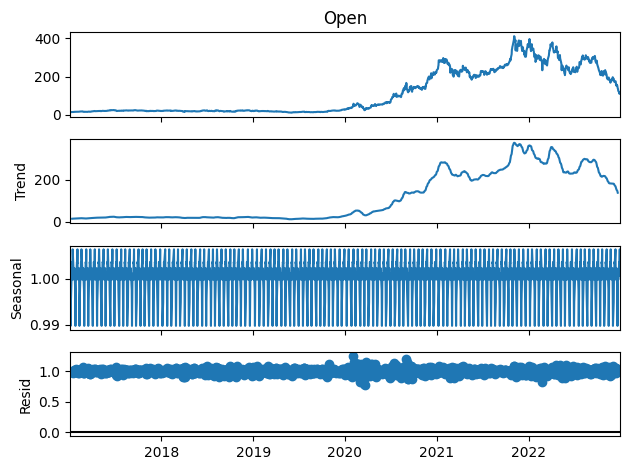

In [35]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Assurez-vous que l'index est de type DateTimeIndex
tesla.index = pd.to_datetime(tesla.index)

# Créez une copie de la colonne 'Open' pour l'analyse
analysis = tesla['Open'].copy()

# Effectuez la décomposition saisonnière en spécifiant une période
decompose_result_mult = seasonal_decompose(analysis, model="multiplicative", period=12)  # Vous pouvez remplacer 12 par la période appropriée

# Récupérez les composantes de la décomposition
trend = decompose_result_mult.trend
seasonal = decompose_result_mult.seasonal
residual = decompose_result_mult.resid

# Affichez le résultat de la décomposition saisonnière
decompose_result_mult.plot();

## Pour Ford

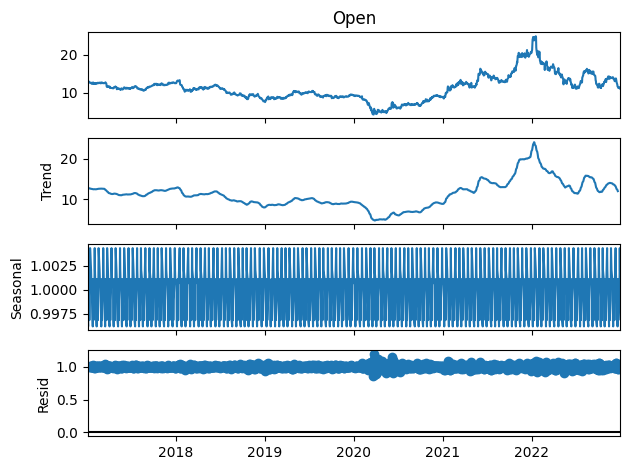

In [36]:
# Assurez-vous que l'index est de type DateTimeIndex
ford.index = pd.to_datetime(ford.index)

# Créez une copie de la colonne 'Open' pour l'analyse
analysis = ford['Open'].copy()

# Effectuez la décomposition saisonnière en spécifiant une période
decompose_result_mult = seasonal_decompose(analysis, model="multiplicative", period=12)  # Vous pouvez remplacer 12 par la période appropriée

# Récupérez les composantes de la décomposition
trend = decompose_result_mult.trend
seasonal = decompose_result_mult.seasonal
residual = decompose_result_mult.resid

# Affichez le résultat de la décomposition saisonnière
decompose_result_mult.plot();

La courbe des prix à l'ouverture de Tesla et de celle de Ford (Xt) est la résultante de différentes composantes fondamentales :
* la tendance (ou trend) (Zt ) qui
représente l’évolution à long terme du prix à l'ouverture. Elle traduit son comportement "moyen".
* la composante saisonnière (ou saisonnalité) (St )
correspond à un phénomène qui se répète à intervalles de temps réguliers (périodiques). En général, c’est un phénomène saisonnier d’où le terme de variations saisonnières.
* la composante résiduelle (ou bruit ou résidu) (εt)
correspond à des fluctuations irrégulières, en général de faible intensité mais de nature aléatoire. On parle aussi d’aléas.



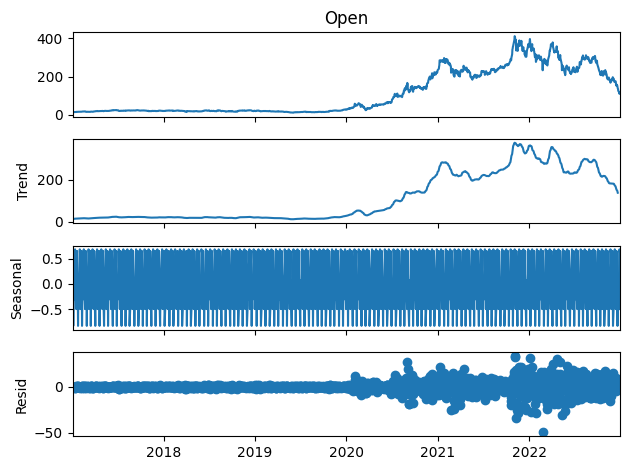

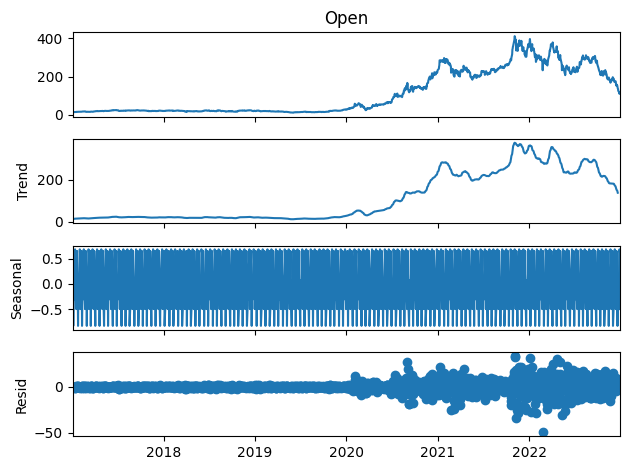

In [37]:
# Assurez-vous que l'index est de type DateTimeIndex
#ford.index = pd.to_datetime(ford.index)

# Créez une copie de la colonne 'Open' pour l'analyse
analysis = tesla['Open'].copy()

# Effectuez la décomposition saisonnière en spécifiant une période et en utilisant un modèle additif
decompose_result_add = seasonal_decompose(analysis, model="additive", period=12)  # Vous pouvez remplacer 12 par la période appropriée

# Récupérez les composantes de la décomposition
trend_add = decompose_result_add.trend
seasonal_add = decompose_result_add.seasonal
residual_add = decompose_result_add.resid

# Affichez le résultat de la décomposition saisonnière
decompose_result_add.plot()

#**Analyse de la tendance**

##Lissage par moyennes mobiles simples

Les moyennes mobiles permettent de lisser directement la série sans hypothèse a priori sur la forme du modèle sous-jacent.
Valable quelque soit le modèle de décomposition.

***Avantages*** : Outil simple à mettre en œuvre qui met en évidence l’allure de la tendance en supprimant la composante saisonnière et en atténuant le bruit.

***Lissage de Tesla***

In [38]:
tesla['MA50'] = tesla['Close'].rolling(50).mean()
tesla['MA200'] = tesla['Close'].rolling(200).mean()

In [39]:
import plotly.graph_objects as go

# Créer une figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Close'
fig.add_trace(go.Scatter(x=tesla.index, y=tesla['Close'], mode='lines', name='Close'))

# Ajouter la série de données pour la colonne 'MA50'
fig.add_trace(go.Scatter(x=tesla.index, y=tesla['MA50'], mode='lines', name='MA50'))

# Ajouter la série de données pour la colonne 'MA200'
fig.add_trace(go.Scatter(x=tesla.index, y=tesla['MA200'], mode='lines', name='MA200'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Close, MA50 et MA200 pour Tesla',
                  xaxis_title='Date',
                  yaxis_title='Price')

# Afficher la figure
fig.show()

***Lissage de Ford***

In [40]:
ford['MA50'] = ford['Close'].rolling(50).mean()
ford['MA200'] = ford['Close'].rolling(200).mean()

In [41]:
import plotly.graph_objects as go

# Créer une figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Close'
fig.add_trace(go.Scatter(x=ford.index, y=ford['Close'], mode='lines', name='Close'))

# Ajouter la série de données pour la colonne 'MA50'
fig.add_trace(go.Scatter(x=ford.index, y=ford['MA50'], mode='lines', name='MA50'))

# Ajouter la série de données pour la colonne 'MA200'
fig.add_trace(go.Scatter(x=ford.index, y=ford['MA200'], mode='lines', name='MA200'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Close, MA50 et MA200 Pour Ford',
                  xaxis_title='Date',
                  yaxis_title='Price')

# Afficher la figure
fig.show()

Le lissage s'obtient en conservant la tendance, en supprimant la composante saisonnière et en atténuant la composante résiduelle (le bruit).

***Interpretation***

De manière générale: Lorsque la moyenne mobile simple (SMA) augmente, cela indique généralement une tendance haussière, ce qui signifie que les prix des actions augmentent en moyenne sur la période donnée. À l'inverse, lorsque la SMA diminue, cela suggère une tendance baissière, avec des prix moyens en baisse sur la période. Les croisements entre différentes périodes de SMA (par exemple, une SMA à court terme croisant une SMA à long terme) peuvent également signaler des changements de tendance potentiels.



* **Ford** : Nous constatons une tendance baissière dans la dernier trimestre de l'année 2020 , ce qui a entraîné une baisse des prix moyens.

* **Tesla** : Nous avons une tendance haussière de 2017 à 2023

##Lissage par moyennes mobiles exponentielles

***Lissage de Tesla***

In [42]:
# Calculer la moyenne mobile exponentielle (MME) sur 50 jours et 200 jours
tesla['EMA50'] = tesla['Close'].ewm(span=50, adjust=False).mean()
tesla['EMA200'] = tesla['Close'].ewm(span=200, adjust=False).mean()

In [43]:
import plotly.graph_objects as go

# Créer une figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Close'
fig.add_trace(go.Scatter(x=tesla.index, y=tesla['Close'], mode='lines', name='Close'))

# Ajouter la série de données pour la colonne 'EMA50'
fig.add_trace(go.Scatter(x=tesla.index, y=tesla['EMA50'], mode='lines', name='EMA50'))

# Ajouter la série de données pour la colonne 'EMA200'
fig.add_trace(go.Scatter(x=tesla.index, y=tesla['EMA200'], mode='lines', name='EMA200'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Close, EMA50 et EMA200 pour Tesla',
                  xaxis_title='Date',
                  yaxis_title='Price')

# Afficher la figure
fig.show()

***Lissage de Ford***

In [44]:
ford['EMA50'] = ford['Close'].ewm(span=50, adjust=False).mean()
ford['EMA200'] = ford['Close'].ewm(span=200, adjust=False).mean()

In [45]:
import plotly.graph_objects as go

# Créer une figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Close'
fig.add_trace(go.Scatter(x=ford.index, y=ford['Close'], mode='lines', name='Close'))

# Ajouter la série de données pour la colonne 'EMA50'
fig.add_trace(go.Scatter(x=ford.index, y=ford['EMA50'], mode='lines', name='EMA50'))

# Ajouter la série de données pour la colonne 'EMA200'
fig.add_trace(go.Scatter(x=ford.index, y=ford['EMA200'], mode='lines', name='EMA200'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Close, EMA50 et EMA200 pour Ford',
                  xaxis_title='Date',
                  yaxis_title='Price')

# Afficher la figure
fig.show()

***Interpretation***

Comme pour la SMA, lorsque l'EMA augmente, cela suggère une tendance haussière, et lorsque l'EMA diminue, cela suggère une tendance baissière. Cependant, l'EMA réagira plus rapidement aux changements de prix, ce qui peut être avantageux pour repérer les tendances émergentes plus tôt.

##Bandes de BOLLINGER

Les bandes de Bollinger sont deux lignes placées à distance fixe au-dessus et au-dessous d’une moyenne mobile donnée, formant un canal (traditionnellement MME de 20 séances et de ± 2 σ) prenant en compte la volatilité.
Lorsque les cours sortent de la bande supérieure, la valeur croît avec force. L’inverse pour la bande du bas. Plus les cours varient vite dans les deux sens, plus les bandes s’écartent.

In [48]:
# Calculons la moyenne mobile sur 30 jours pour la colonne 'Close'
tesla['Close:30_Day_Mean'] = tesla['Close'].rolling(window=30).mean()

In [50]:
# Calculons l'écart-type sur 30 jours pour la colonne 'Close'
tesla['Close:30_Day_Std'] = tesla['Close'].rolling(window=30).std()

# Calculons les bornes supérieure et inférieure de la bande de Bollinger
tesla['Upper'] = tesla['Close:30_Day_Mean'] + 2 * tesla['Close:30_Day_Std']
tesla['Lower'] = tesla['Close:30_Day_Mean'] - 2 * tesla['Close:30_Day_Std']

In [51]:
import plotly.graph_objects as go

# Créer une figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Close:30_Day_Mean'
fig.add_trace(go.Scatter(x=tesla.index[-100:], y=tesla['Close:30_Day_Mean'].tail(100), mode='lines', name='Close:30_Day_Mean'))

# Ajouter la série de données pour la colonne 'Upper'
fig.add_trace(go.Scatter(x=tesla.index[-100:], y=tesla['Upper'].tail(100), mode='lines', name='Upper'))

# Ajouter la série de données pour la colonne 'Lower'
fig.add_trace(go.Scatter(x=tesla.index[-100:], y=tesla['Lower'].tail(100), mode='lines', name='Lower'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Close:30_Day_Mean, Upper et Lower pour Tesla',
                  xaxis_title='Date',
                  yaxis_title='Prix')

# Afficher la figure
fig.show()

In [52]:
# Calculons la moyenne mobile sur 30 jours pour la colonne 'Close'
ford['Close:30_Day_Mean'] = ford['Close'].rolling(window=30).mean()
# Calculons l'écart-type sur 30 jours pour la colonne 'Close'
ford['Close:30_Day_Std'] = ford['Close'].rolling(window=30).std()

# Calculons les bornes supérieure et inférieure de la bande de Bollinger
ford['Upper'] = ford['Close:30_Day_Mean'] + 2 * ford['Close:30_Day_Std']
ford['Lower'] = ford['Close:30_Day_Mean'] - 2 * ford['Close:30_Day_Std']

In [53]:
import plotly.graph_objects as go

# Créer une figure
fig = go.Figure()

# Ajouter la série de données pour la colonne 'Close:30_Day_Mean'
fig.add_trace(go.Scatter(x=ford.index[-100:], y=ford['Close:30_Day_Mean'].tail(100), mode='lines', name='Close:30_Day_Mean'))

# Ajouter la série de données pour la colonne 'Upper'
fig.add_trace(go.Scatter(x=ford.index[-100:], y=ford['Upper'].tail(100), mode='lines', name='Upper'))

# Ajouter la série de données pour la colonne 'Lower'
fig.add_trace(go.Scatter(x=ford.index[-100:], y=ford['Lower'].tail(100), mode='lines', name='Lower'))

# Mettre en forme le titre et les axes
fig.update_layout(title='Close:30_Day_Mean, Upper et Lower pour Ford',
                  xaxis_title='Date',
                  yaxis_title='Prix')

# Afficher la figure
fig.show()

La ligne bleue représente la moyenne mobile sur 30 jours des prix de clôture de Tesla. Cette moyenne agit comme un filtre qui lisse les fluctuations à court terme des prix, mettant en évidence la tendance générale. Lorsque la ligne bleue monte, cela suggère une tendance haussière, indiquant que les prix augmentent en moyenne sur la période. À l'inverse, lorsque la ligne bleue descend, cela suggère une tendance baissière, avec des prix moyens en baisse sur la période.